In [59]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [60]:
df = pd.read_csv('ai_job_dataset.csv')

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  str    
 1   job_title               15000 non-null  str    
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  str    
 4   experience_level        15000 non-null  str    
 5   employment_type         15000 non-null  str    
 6   company_location        15000 non-null  str    
 7   company_size            15000 non-null  str    
 8   employee_residence      15000 non-null  str    
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  str    
 11  education_required      15000 non-null  str    
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  str    
 14  posting_date            15000 non-null  str    
 

In [62]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [63]:
df.shape

(15000, 19)

In [64]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='str')

In [65]:
df["posting_date"] = pd.to_datetime(df["posting_date"])
df["application_deadline"] = pd.to_datetime(df["application_deadline"])

In [66]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df["job_id"].duplicated().sum()

np.int64(0)

In [69]:
df.describe()

,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000,15000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,2024-08-29 08:48:51.840000,2024-10-11 21:55:23.520000,1503.314733,7.504273
min,32519.000000,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,2024-04-29 00:00:00,2024-06-13 00:00:00,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,2024-08-28 00:00:00,2024-10-12 00:00:00,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2024-12-29 00:00:00,2025-02-10 00:00:00,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000
std,60260.940438,40.812712,5.545768,NaN,NaN,576.127083,1.450870


Analyzing the target variable

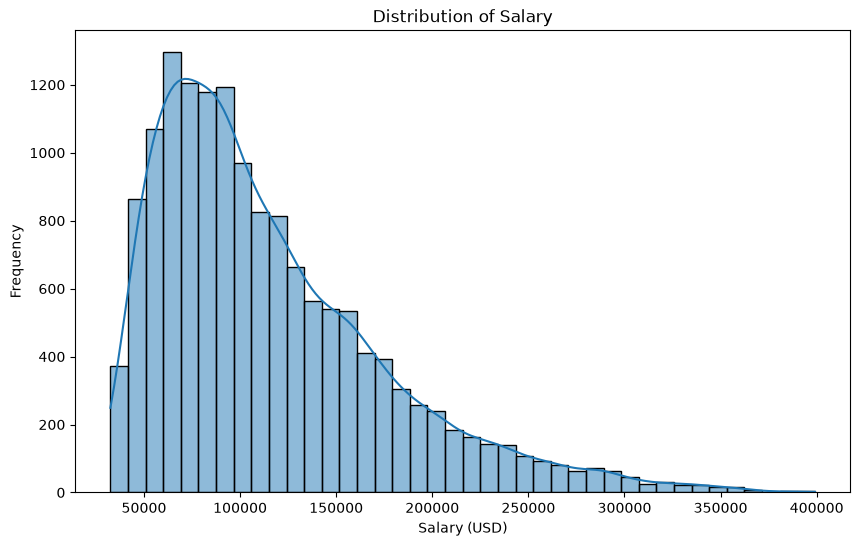

In [70]:
plt.figure(figsize=(10, 6))

sns.histplot(df["salary_usd"], bins=40, kde=True)

plt.title("Distribution of Salary")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

Boxplot of salary

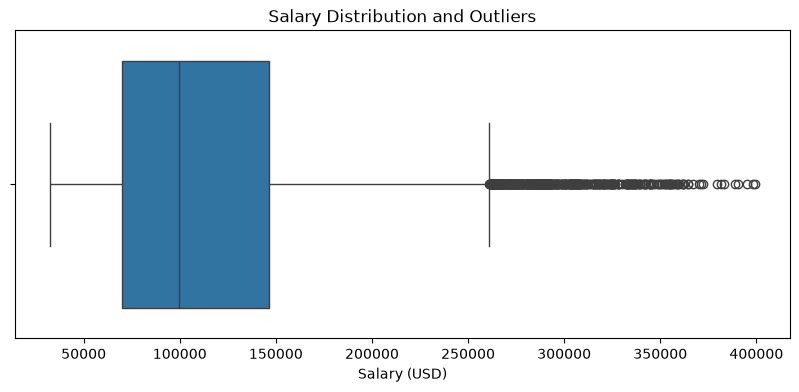

In [71]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["salary_usd"])

plt.title("Salary Distribution and Outliers")
plt.xlabel("Salary (USD)")

plt.show()

Analyzing numerical features

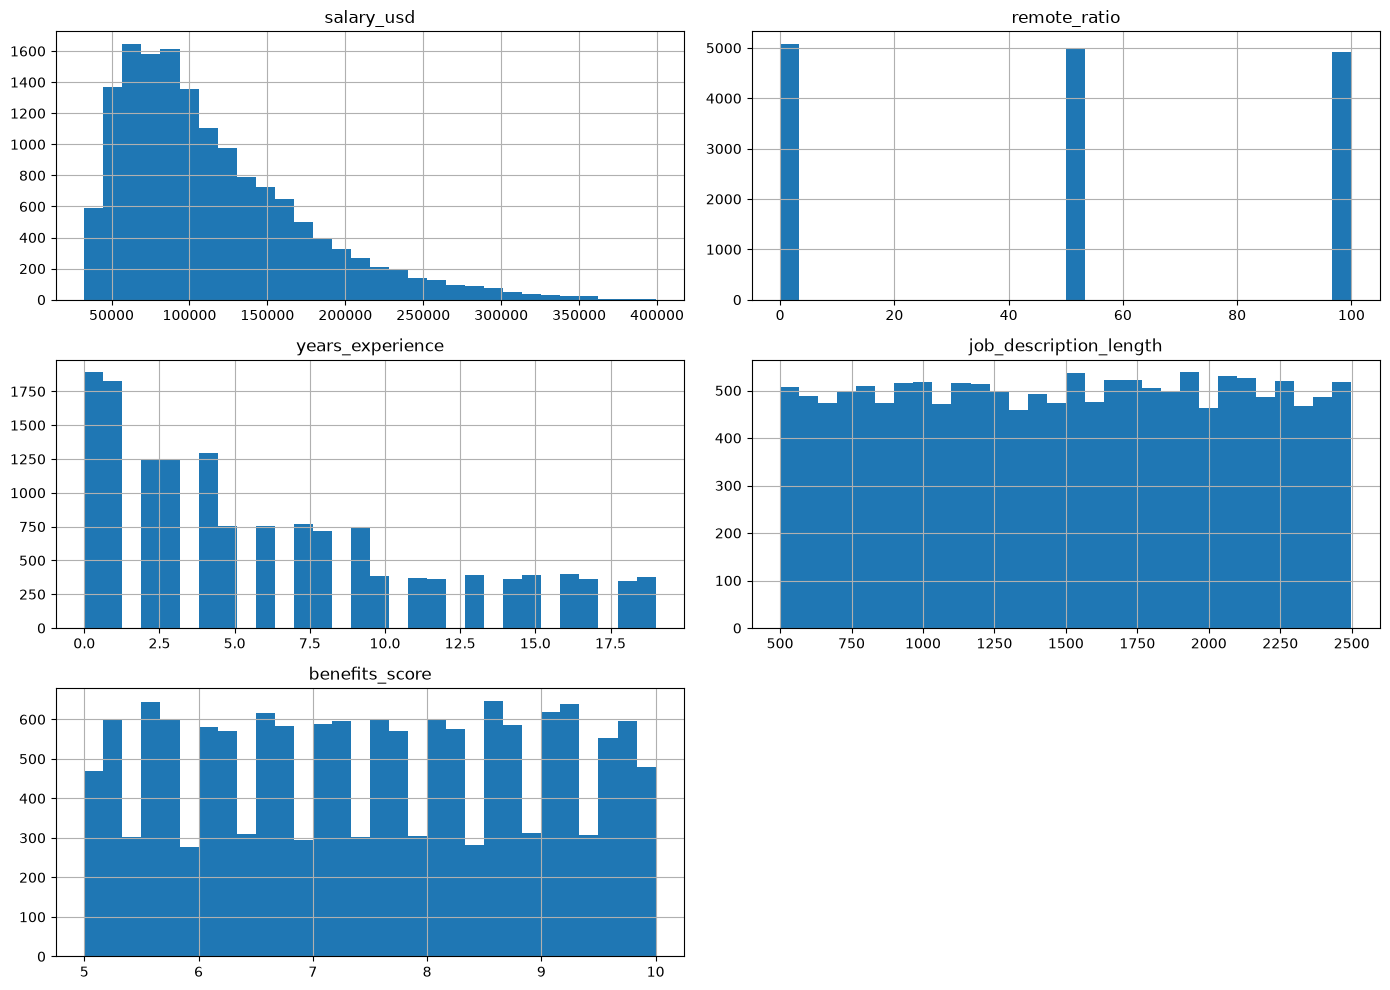

In [72]:
numerical_columns = [
    "salary_usd",
    "remote_ratio",
    "years_experience",
    "job_description_length",
    "benefits_score"
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [73]:
correlation = df[numerical_columns].corr()

correlation

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
salary_usd,1.000000,0.013727,0.737556,-0.009092,0.000985
remote_ratio,0.013727,1.000000,0.015321,0.004475,0.003139
years_experience,0.737556,0.015321,1.000000,-0.007526,-0.007275
job_description_length,-0.009092,0.004475,-0.007526,1.000000,0.006744
benefits_score,0.000985,0.003139,-0.007275,0.006744,1.000000


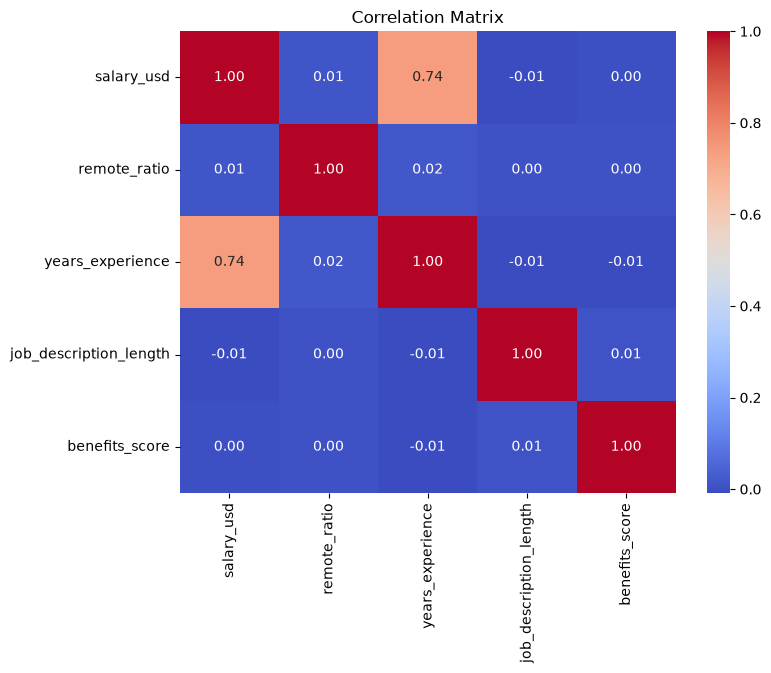

In [74]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Salary vs experience

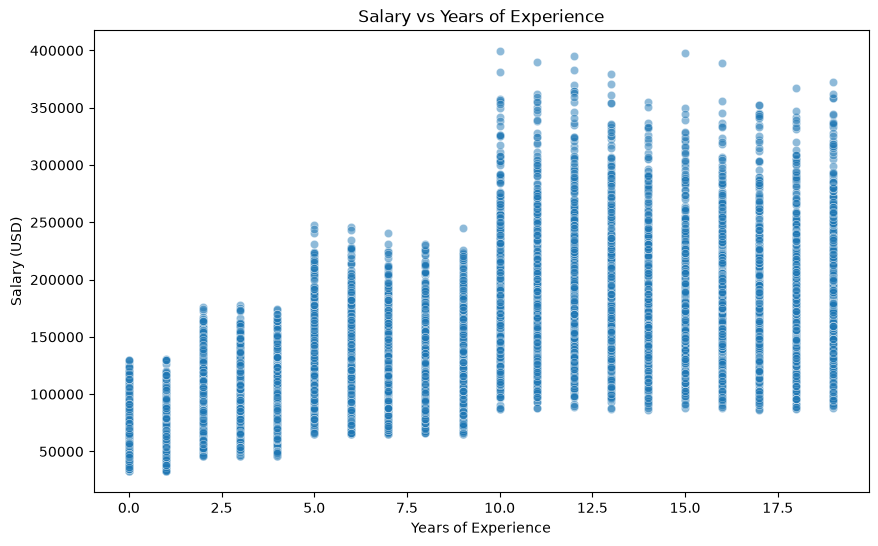

In [75]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary_usd",
    alpha=0.5
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

plt.show()

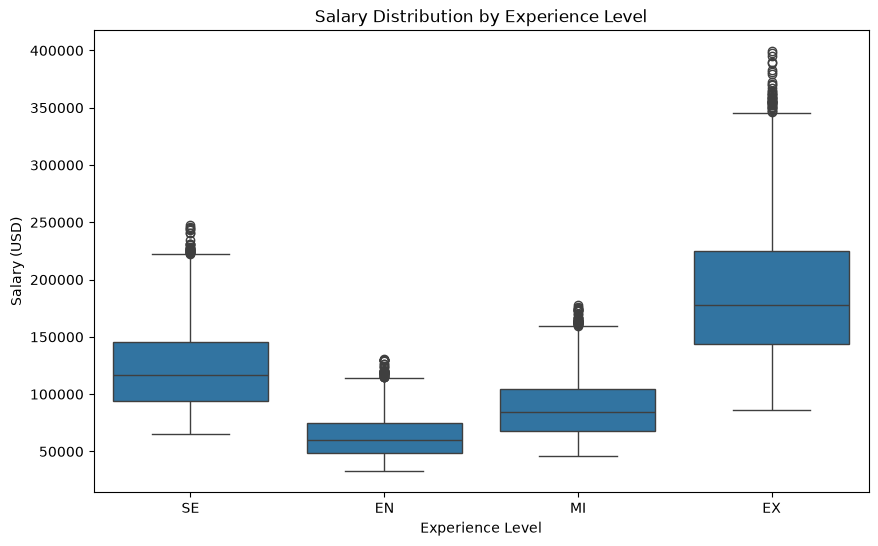

In [76]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_usd"
)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

Salary by experience level

In [77]:
df.groupby("experience_level")["salary_usd"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

,count,mean,median,min,max
experience_level,,,,,
EX,3760,187723.647340,177512.0,86536,399095
SE,3741,122187.657845,116907.0,64824,247271
MI,3781,87955.471833,84641.0,45900,177470
EN,3718,63133.377084,60373.5,32519,131006


Salary by job title

In [78]:
df["job_title"].nunique()

20

In [79]:
job_salary = (
    df.groupby("job_title")["salary_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

job_salary

,count,mean,median
job_title,,,
AI Specialist,728,120570.758242,103626.5
Machine Learning Engineer,772,118827.919689,103687.0
Head of AI,765,118542.968627,102025.0
AI Research Scientist,756,117897.925926,100990.0
AI Architect,771,117436.513619,99888.0
Robotics Engineer,759,116470.793149,100714.0
Principal Data Scientist,734,116305.219346,98712.0
Research Scientist,742,116066.502695,99446.5
Data Engineer,749,115970.720961,104447.0


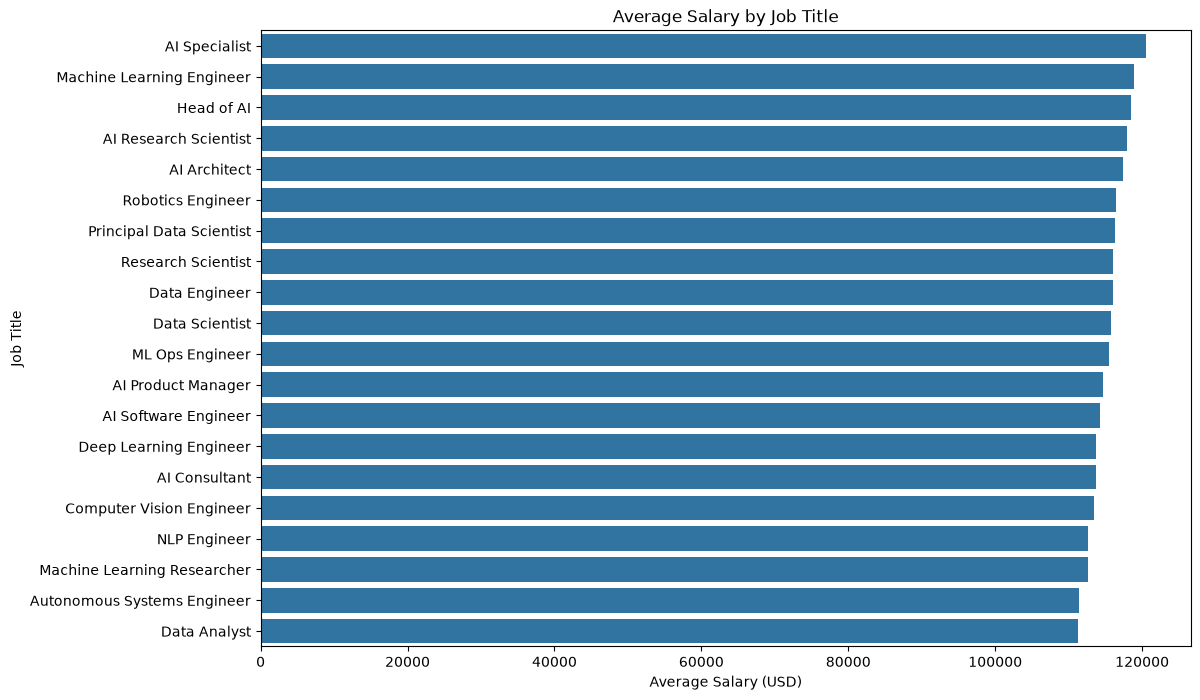

In [80]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=job_salary.reset_index(),
    x="mean",
    y="job_title"
)

plt.title("Average Salary by Job Title")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.show()

Salary by company size

In [81]:
df.groupby("company_size")["salary_usd"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
company_size,,,
L,4998,130322.451781,114564.0
M,4995,113600.237037,98122.0
S,5007,102146.930098,89648.0


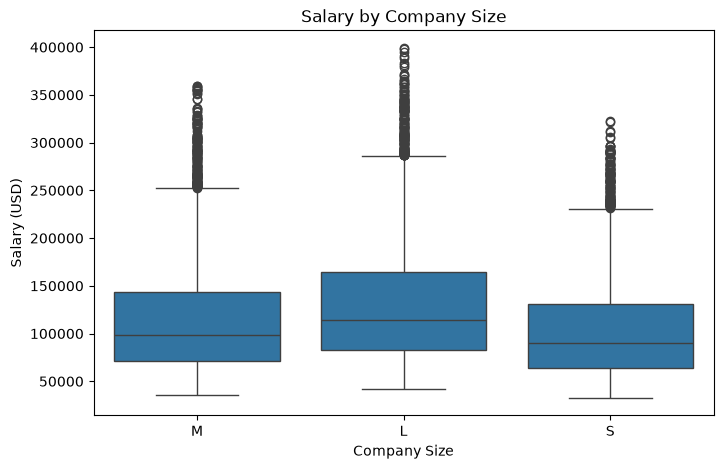

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="company_size",
    y="salary_usd"
)

plt.title("Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.show()

Salary by education

In [83]:
df.groupby("education_required")["salary_usd"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
education_required,,,
Master,3748,117171.815902,102553.5
Bachelor,3789,115861.629190,99087.0
Associate,3785,114605.708058,99139.0
PhD,3678,113728.165579,97171.5


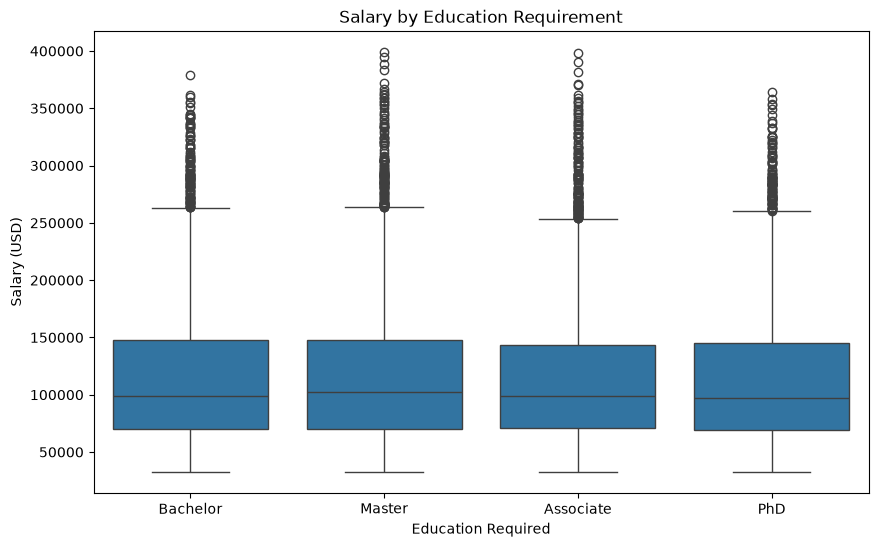

In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="education_required",
    y="salary_usd"
)

plt.title("Salary by Education Requirement")
plt.xlabel("Education Required")
plt.ylabel("Salary (USD)")

plt.show()

Salary by employment type

In [85]:
df.groupby("employment_type")["salary_usd"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
employment_type,,,
FT,3812,116338.137723,100421.5
CT,3721,115918.919645,100445.0
FL,3758,114967.645290,99603.5
PT,3709,114146.881909,98201.0


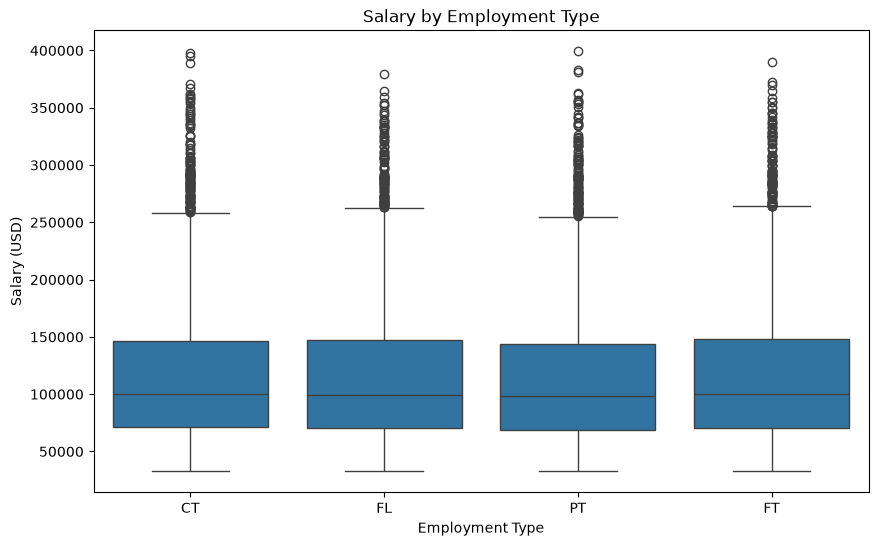

In [86]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="employment_type",
    y="salary_usd"
)

plt.title("Salary by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Salary (USD)")

plt.show()

Salary by industry

In [87]:
df["industry"].value_counts()

industry
Retail                1063
Media                 1045
Automotive            1020
Consulting            1020
Technology            1011
Real Estate           1007
Government             998
Healthcare             997
Telecommunications     997
Transportation         997
Finance                984
Energy                 976
Gaming                 967
Manufacturing          962
Education              956
Name: count, dtype: int64

In [88]:
industry_salary = (
    df.groupby("industry")["salary_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

industry_salary

,count,mean,median
industry,,,
Consulting,1020,117602.142157,100983.5
Manufacturing,962,116162.888773,100007.0
Media,1045,116127.730144,100272.0
Education,956,116026.803347,101097.5
Real Estate,1007,115919.095333,98126.0
Technology,1011,115831.823937,99539.0
Government,998,115694.321643,101914.5
Finance,984,115323.398374,101409.0
Telecommunications,997,115291.411234,102408.0


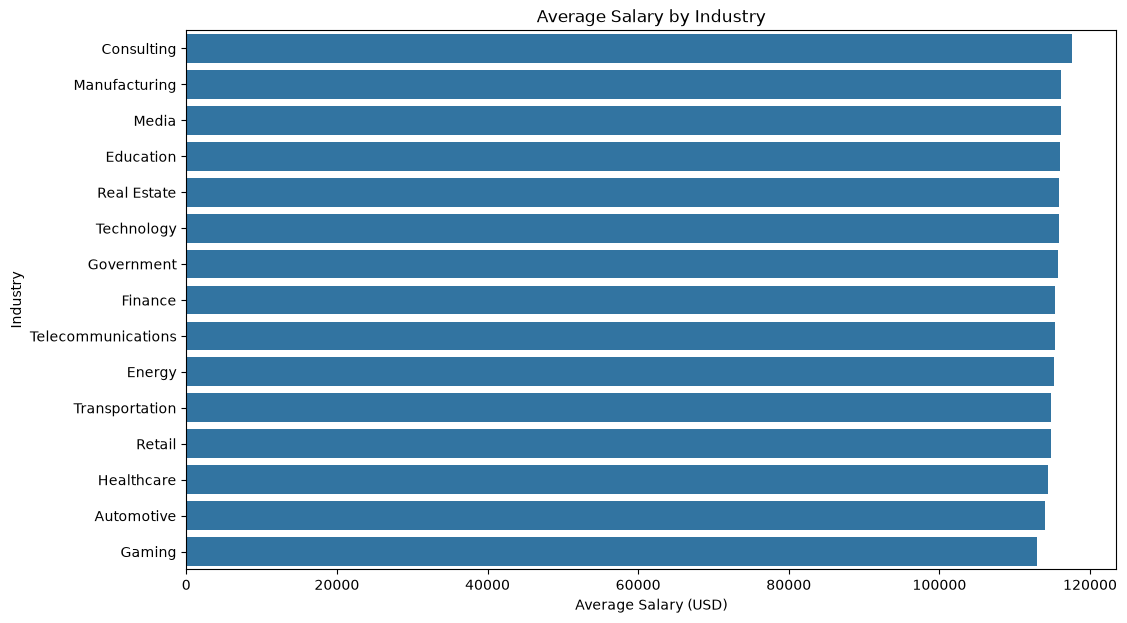

In [89]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=industry_salary.reset_index(),
    x="mean",
    y="industry"
)

plt.title("Average Salary by Industry")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Industry")

plt.show()

Remote work and salary

In [90]:
df.groupby("remote_ratio")["salary_usd"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
remote_ratio,,,
0,5075,114140.231133,98817.0
50,5005,115776.806793,99295.0
100,4920,116160.545935,100614.0


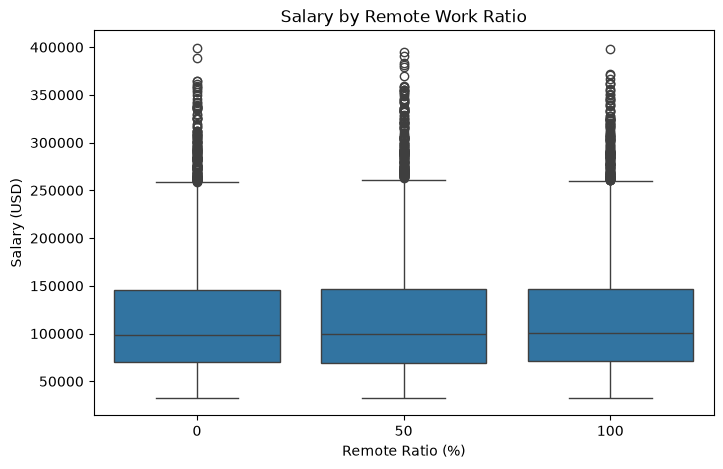

In [91]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="remote_ratio",
    y="salary_usd"
)

plt.title("Salary by Remote Work Ratio")
plt.xlabel("Remote Ratio (%)")
plt.ylabel("Salary (USD)")

plt.show()

Benefits score vs salary

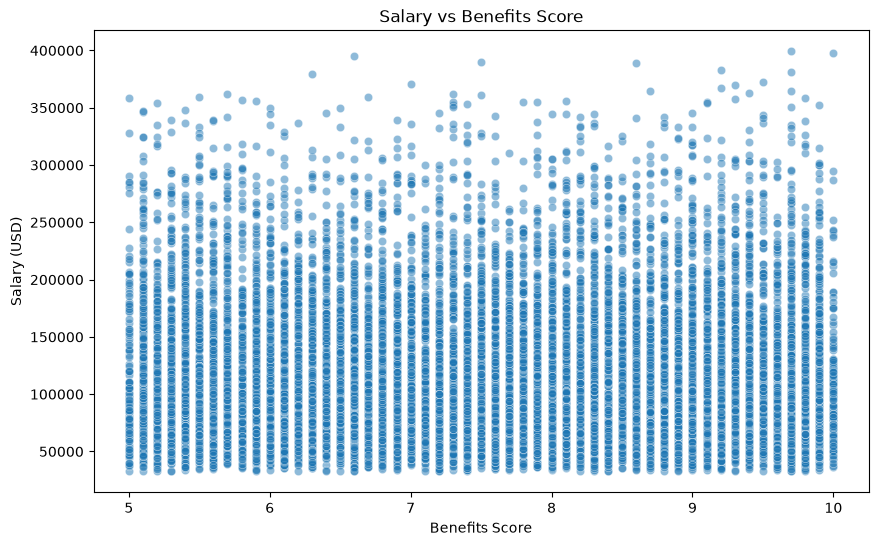

In [92]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="benefits_score",
    y="salary_usd",
    alpha=0.5
)

plt.title("Salary vs Benefits Score")
plt.xlabel("Benefits Score")
plt.ylabel("Salary (USD)")

plt.show()

In [93]:
df[["benefits_score", "salary_usd"]].corr()

,benefits_score,salary_usd
benefits_score,1.000000,0.000985
salary_usd,0.000985,1.000000


Job description length vs salary

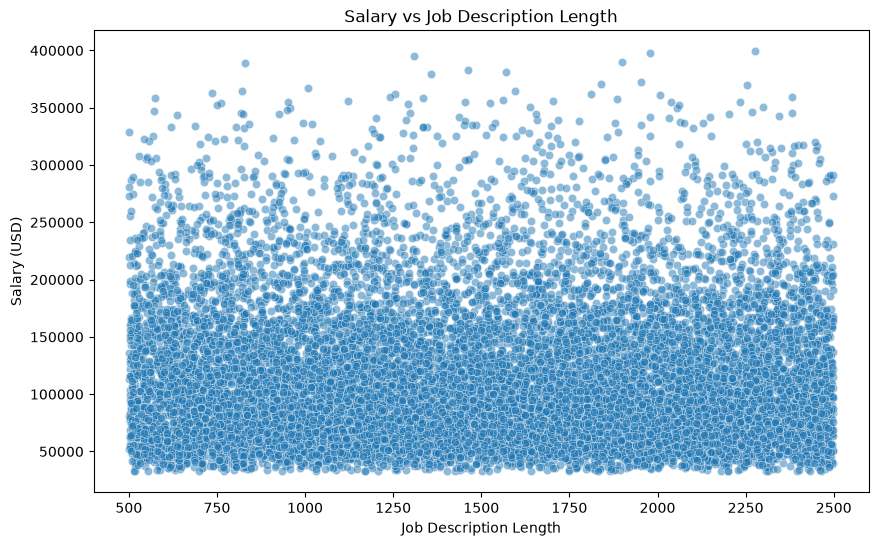

In [94]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="job_description_length",
    y="salary_usd",
    alpha=0.5
)

plt.title("Salary vs Job Description Length")
plt.xlabel("Job Description Length")
plt.ylabel("Salary (USD)")

plt.show()

Check categorical distributions

In [95]:
categorical_columns = [
    "job_title",
    "salary_currency",
    "experience_level",
    "employment_type",
    "company_location",
    "company_size",
    "employee_residence",
    "education_required",
    "industry",
    "company_name"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


job_title
job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Data Analyst                   759
Robotics Engineer              759
AI Research Scientist          756
Data Engineer                  749
AI Product Manager             743
Research Scientist             742
Principal Data Scientist       734
AI Specialist                  728
ML Ops Engineer                725
Computer Vision Engineer       724
Data Scientist                 720
Deep Learning Engineer         718
AI Consultant                  704
Name: count, dtype: int64

salary_currency
salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64

experience_level
experience_level
MI    3781
EX    3760
SE    3741
EN    3718
Name: count, dtype: int64

employment_type
employment_type
FT    3812
FL    

Investigate salary currency

In [96]:
df.groupby("salary_currency")["salary_usd"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
salary_currency,,,,,
EUR,2314,120912.002593,107139.5,43226,309752
GBP,729,128720.186557,115281.0,48743,310470
USD,11957,113457.145354,96951.0,32519,399095


Check date columns

In [97]:
df[["posting_date", "application_deadline"]].describe()

,posting_date,application_deadline
count,15000,15000
mean,2024-08-29 08:48:51.840000,2024-10-11 21:55:23.520000
min,2024-01-01 00:00:00,2024-01-16 00:00:00
25%,2024-04-29 00:00:00,2024-06-13 00:00:00
50%,2024-08-28 00:00:00,2024-10-12 00:00:00
75%,2024-12-29 00:00:00,2025-02-10 00:00:00
max,2025-04-30 00:00:00,2025-07-11 00:00:00


In [98]:
df["days_to_deadline"] = (
    df["application_deadline"] - df["posting_date"]
).dt.days

In [99]:
df["days_to_deadline"].describe()

count    15000.000000
mean        43.546200
std         17.325134
min         14.000000
25%         29.000000
50%         44.000000
75%         59.000000
max         74.000000
Name: days_to_deadline, dtype: float64

Check required_skills

In [100]:
df["required_skills"].head(20)

0            Tableau, PyTorch, Kubernetes, Linux, NLP
1     Deep Learning, AWS, Mathematics, Python, Docker
2        Kubernetes, Deep Learning, Java, Hadoop, NLP
3                           Scala, SQL, Linux, Python
4                        MLOps, Java, Tableau, Python
5                   Data Visualization, R, SQL, Linux
6                                    R, Docker, MLOps
7           Python, SQL, Computer Vision, Java, Azure
8                    Hadoop, Git, Mathematics, Python
9                     MLOps, GCP, Scala, Azure, Linux
10                                 MLOps, Python, SQL
11               R, Data Visualization, Python, Azure
12                        Tableau, Python, TensorFlow
13                             Scala, SQL, Statistics
14           PyTorch, Python, Data Visualization, GCP
15                   Linux, Statistics, Deep Learning
16                                Tableau, NLP, Spark
17                              MLOps, PyTorch, Azure
18                      Git,

In [101]:
df["required_skills"].nunique()

13663

Check company name

In [102]:
df["company_name"].nunique()

16

In [103]:
df.groupby("company_name")["salary_usd"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
company_name,,,
TechCorp Inc,980,121268.360204,103209.0
Neural Networks Co,922,118660.359002,103316.5
Autonomous Tech,918,116788.314815,103352.0
Machine Intelligence Group,922,116784.366594,96869.0
Cloud AI Solutions,951,116744.533123,102474.0
Future Systems,960,116271.155208,100107.0
DeepTech Ventures,897,115812.198439,99115.0
Quantum Computing Inc,960,115322.491667,101047.5
DataVision Ltd,909,115296.632563,98760.0


drop job_id

In [104]:
df = df.drop(columns=["job_id"])

In [106]:
# Create useful date features
df["posting_year"] = df["posting_date"].dt.year
df["posting_month"] = df["posting_date"].dt.month
df["days_to_deadline"] = (
    df["application_deadline"] - df["posting_date"]
).dt.days

In [108]:
# Create skill-based features
skills = sorted(
    set(
        skill.strip()
        for values in df["required_skills"].dropna()
        for skill in values.split(",")
    )
)

for skill in skills:
    column_name = "skill_" + skill.lower().replace(" ", "_")

    df[column_name] = df["required_skills"].fillna("").apply(
        lambda x: int(skill in [s.strip() for s in x.split(",")])
    )

In [110]:
# Drop columns that we don't need
df = df.drop(
    columns=[
        "required_skills",
        "posting_date",
        "application_deadline"
    ]
)

df.head()

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,...,skill_nlp,skill_pytorch,skill_python,skill_r,skill_sql,skill_scala,skill_spark,skill_statistics,skill_tableau,skill_tensorflow
0,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,Bachelor,...,1,1,0,0,0,0,0,0,1,0
1,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,Master,...,0,0,1,0,0,0,0,0,0,0
2,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,Associate,...,1,0,0,0,0,0,0,0,0,0
3,NLP Engineer,80215,USD,SE,FL,India,M,India,50,PhD,...,0,0,1,0,1,1,0,0,0,0
4,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,Master,...,0,0,1,0,0,0,0,0,1,0


In [111]:
# Input Features
X = df.drop("salary_usd", axis=1)

# Target
y = df["salary_usd"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 41)
y shape: (15000,)


In [115]:
# Categorical columns
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

# Numerical columns
numerical_features = X.select_dtypes(
    exclude=["object", "str"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['job_title', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'education_required', 'industry', 'company_name']

Numerical Features:
['remote_ratio', 'years_experience', 'job_description_length', 'benefits_score', 'days_to_deadline', 'posting_year', 'posting_month', 'skill_aws', 'skill_azure', 'skill_computer_vision', 'skill_data_visualization', 'skill_deep_learning', 'skill_docker', 'skill_gcp', 'skill_git', 'skill_hadoop', 'skill_java', 'skill_kubernetes', 'skill_linux', 'skill_mlops', 'skill_mathematics', 'skill_nlp', 'skill_pytorch', 'skill_python', 'skill_r', 'skill_sql', 'skill_scala', 'skill_spark', 'skill_statistics', 'skill_tableau', 'skill_tensorflow']


Train-Test-Split

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12000, 41)
Testing data: (3000, 41)


## Model Building: Preprocessing → Feature Selection → Hyperparameter Tuning → Model Evaluation

We continue from the train-test split above. The target is `salary_usd`, so this is a regression task.  
The workflow below keeps preprocessing and feature selection **inside each cross-validation fold** to avoid data leakage.


In [127]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Re-create feature lists from the current X dataframe
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object", "str"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)


Categorical features: ['job_title', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'education_required', 'industry', 'company_name']
Numerical features: ['remote_ratio', 'years_experience', 'job_description_length', 'benefits_score', 'days_to_deadline', 'posting_year', 'posting_month', 'skill_aws', 'skill_azure', 'skill_computer_vision', 'skill_data_visualization', 'skill_deep_learning', 'skill_docker', 'skill_gcp', 'skill_git', 'skill_hadoop', 'skill_java', 'skill_kubernetes', 'skill_linux', 'skill_mlops', 'skill_mathematics', 'skill_nlp', 'skill_pytorch', 'skill_python', 'skill_r', 'skill_sql', 'skill_scala', 'skill_spark', 'skill_statistics', 'skill_tableau', 'skill_tensorflow']


In [128]:
# 1. PREPROCESSING
# Numerical: median imputation + standardization
# Categorical: most-frequent imputation + one-hot encoding

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Feature selection is deliberately placed after preprocessing.
# f_regression ranks transformed features by their relationship with salary.
feature_selector = SelectKBest(score_func=f_regression)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

print("Preprocessing and feature-selection pipeline created.")


Preprocessing and feature-selection pipeline created.


### 2. Feature Selection

`SelectKBest(f_regression)` is used after encoding. The number of retained features (`k`) is tuned along with the model hyperparameters, so feature selection is part of the model-selection process.


In [132]:
# 3. DEFINE MODELS + HYPERPARAMETER GRIDS

model_configs = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {
            "selector__k": [15, 25, 35, "all"]
        }
    },

    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "selector__k": [15, 25, 35],
            "model__n_neighbors": [5, 10, 20],
            "model__weights": ["uniform", "distance"]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "selector__k": [15, 25, 35, "all"],
            "model__max_depth": [8, 15, None],
            "model__min_samples_split": [2, 10]
        }
    },

    "Random Forest (Ensemble)": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=1
        ),
        "params": {
            "selector__k": [15, 25, 35, "all"],
            "model__n_estimators": [100, 200],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5]
        }
    }
}

print("Models ready for hyperparameter tuning:")
for name in model_configs:
    print("-", name)

Models ready for hyperparameter tuning:
- Linear Regression
- KNN
- Decision Tree
- Random Forest (Ensemble)


### 4. Hyperparameter Tuning

Grid search uses 3-fold cross-validation and RMSE as the optimization metric. All transformations, feature selection, and model fitting happen within the CV pipeline.


In [133]:
# 5. HYPERPARAMETER TUNING
# Use one worker to avoid nested joblib processes and worker warnings.

best_models = {}
tuning_results = []

for name, config in model_configs.items():
    print(f"\nTuning {name} ...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", config["model"])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
        refit=True,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search

    tuning_results.append({
        "Model": name,
        "Best CV RMSE": -grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print("Best CV RMSE:", -grid_search.best_score_)
    print("Best parameters:", grid_search.best_params_)

tuning_results_df = pd.DataFrame(tuning_results).sort_values("Best CV RMSE")
tuning_results_df


Tuning Linear Regression ...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best CV RMSE: 23556.688683778277
Best parameters: {'selector__k': 'all'}

Tuning KNN ...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best CV RMSE: 21886.220937063856
Best parameters: {'model__n_neighbors': 10, 'model__weights': 'uniform', 'selector__k': 25}

Tuning Decision Tree ...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best CV RMSE: 22114.784788710545
Best parameters: {'model__max_depth': 15, 'model__min_samples_split': 10, 'selector__k': 25}

Tuning Random Forest (Ensemble) ...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best CV RMSE: 21040.11269232672
Best parameters: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200, 'selector__k': 'all'}


,Model,Best CV RMSE,Best Parameters
3,Random Forest (Ensemble),21040.112692,"{'model__max_depth': 20, 'model__min_samples_s..."
1,KNN,21886.220937,"{'model__n_neighbors': 10, 'model__weights': '..."
2,Decision Tree,22114.784789,"{'model__max_depth': 15, 'model__min_samples_s..."
0,Linear Regression,23556.688684,{'selector__k': 'all'}


### 5. Final Model Evaluation on the Test Set

The test set is used only after tuning. We compare:
- **MAE**: lower is better
- **RMSE**: lower is better
- **R²**: higher is better

The model with the lowest RMSE is selected as the best predictive model.


In [134]:
# 6. EVALUATE ALL TUNED MODELS
evaluation_results = []
test_predictions = {}

for name, search in best_models.items():
    model = search.best_estimator_
    predictions = model.predict(X_test)
    test_predictions[name] = predictions

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results_df


,Model,MAE,RMSE,R2 Score
0,Random Forest (Ensemble),15125.858959,21184.873547,0.876947
1,KNN,15574.458167,22068.229281,0.866471
2,Decision Tree,15770.644506,22196.371723,0.864915
3,Linear Regression,17079.997345,23254.532583,0.851729


In [135]:
# 7. IDENTIFY THE BEST MODEL
best_model_name = results_df.loc[0, "Model"]
best_model = best_models[best_model_name].best_estimator_

print("==========================================")
print("BEST MODEL:", best_model_name)
print("==========================================")
print("MAE :", round(results_df.loc[0, "MAE"], 2))
print("RMSE:", round(results_df.loc[0, "RMSE"], 2))
print("R2  :", round(results_df.loc[0, "R2 Score"], 4))
print("\nBest hyperparameters:")
print(best_models[best_model_name].best_params_)


BEST MODEL: Random Forest (Ensemble)
MAE : 15125.86
RMSE: 21184.87
R2  : 0.8769

Best hyperparameters:
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200, 'selector__k': 'all'}


In [136]:
# 8. ACTUAL VS PREDICTED SALARY FOR THE BEST MODEL
best_predictions = test_predictions[best_model_name]

comparison_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": best_predictions
})

comparison_df["Absolute Error"] = (
    comparison_df["Actual Salary"] - comparison_df["Predicted Salary"]
).abs()

comparison_df.head(10)


,Actual Salary,Predicted Salary,Absolute Error
0,138919,150660.273307,11741.273307
1,187208,162527.154017,24680.845983
2,158264,136048.438941,22215.561059
3,139174,169386.119699,30212.119699
4,61622,75645.553561,14023.553561
5,90518,107837.001453,17319.001453
6,84245,71753.532037,12491.467963
7,51038,42328.420051,8709.579949
8,105093,128630.681823,23537.681823
9,54155,68282.794393,14127.794393


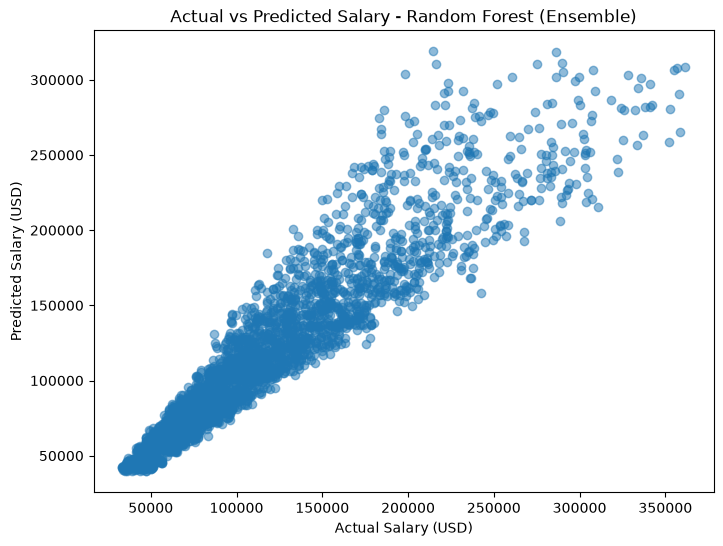

In [137]:
# 9. ACTUAL VS PREDICTED VISUALIZATION
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.5)
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title(f"Actual vs Predicted Salary - {best_model_name}")
plt.show()

### 6. Final Conclusion

After running the cells above, `results_df` gives the direct comparison of all four approaches. The model in the first row is the best according to test-set RMSE.

Because the data contains both categorical and numerical variables, preprocessing is handled with imputation, one-hot encoding, and scaling. Feature selection is performed after preprocessing, and hyperparameters are tuned using cross-validation before the final test-set comparison.
